# Exploratory Data Analysis

This notebook explores the cleaned dataset produced in `I-cleaning.ipynb`: one row per country-year, combining World Bank development indicators with the Heritage Foundation's Index of Economic Freedom for 185 countries between 2001 and 2025 (`data/processed/wb_economic_freedom_merged.csv`).

It examines how economic freedom (property rights, government integrity, trade freedom and the other sub-components) relates to real-world development outcomes (GDP per capita, life expectancy, unemployment, and more), through descriptive statistics, trends over time, and visualisation.

**Parts covered in this notebook:**
1. Imports, loading the cleaned dataset, and initial inspection
2. Global and regional trends over time
3. Relationship between economic freedom and development outcomes
4. Correlation analysis across indicators
5. Key findings and takeaways

<table align="left">
  <tr>
    <td>
      <a href="https://colab.research.google.com/github/ValentimPiazera/wb-economic-freedom/blob/main/notebooks/II-analysis.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
      </a>
    </td>
    <td>
      <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ValentimPiazera/wb-economic-freedom/blob/main/notebooks/II-analysis.ipynb">
        <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle"/>
      </a>
    </td>
  </tr>
</table>

> **Note:** this notebook is written to run from the **repository root**, not from `notebooks/`.
> Locally, `.vscode/settings.json` already points VS Code's Jupyter root at the workspace folder;
> from a terminal, launch Jupyter from the repository root.
>
> If you're running on Google Colab or Kaggle, run the cell below first: it clones the repository
> so that the `src/` module and data files are available.
>
> On **Kaggle**, make sure Internet access is enabled: *Settings → Internet → On*.

In [1]:
try:
    %load_ext autoreload
    %autoreload 2
except ImportError:
    pass

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

REPO = "wb-economic-freedom"
REPO_URL = f"https://github.com/ValentimPiazera/{REPO}.git"
MARKER = "src"
PACKAGES = ["adjustText", "kaleido"]

# Resolve the repository root by looking for the marker directory rather
# than by detecting Colab or Kaggle. What actually matters is whether
# `from src import viz` and the `data/` paths will resolve, and testing
# that directly also covers a notebook launched from `notebooks/` and a repo
# that was already cloned.
if not Path(MARKER).is_dir():
    if Path("..", MARKER).is_dir():
        os.chdir("..")
    elif Path(REPO, MARKER).is_dir():
        os.chdir(REPO)
    else:
        print(f"Cloning {REPO}...")
        clone = subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL],
            capture_output=True,
            text=True,
        )
        if clone.returncode != 0:
            raise RuntimeError(
                f"git clone failed:\n{clone.stderr}\n"
                "On Kaggle this is usually internet access being off: "
                "Settings -> Internet -> On."
            )
        os.chdir(REPO)

# Same principle for the packages: check whether the import resolves rather
# than which platform this is. adjustText places the labels on
# the dense per-continent panels, and kaleido is what plotly shells out
# to when writing the two static stills to figures/.
missing = [
    package
    for package in PACKAGES
    if importlib.util.find_spec(package) is None
]
if missing:
    print(f"Installing {' '.join(missing)}...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *missing], check=True
    )

print("Working directory:", Path.cwd().name)

Working directory: wb-economic-freedom


## Part I | Imports, Loading, and Initial Inspection

Load the cleaned dataset from `data/processed/wb_economic_freedom_merged.csv` and get a first look at its shape, columns, and data types before starting the analysis.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src import cleaning, utils, viz

In [3]:
df = pd.read_csv("data/processed/wb_economic_freedom_merged.csv")

df.head()

,Country Name,Country Code,Year,Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),"Foreign direct investment, net inflows (% of GDP)",GDP (current US$),GDP growth (annual %),"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)","Population, total",...,Tax Burden,Government Spending,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,GDP per capita (current US$),Continent
0,Afghanistan,AFG,2001,0.9402,0.02,2.813572e+09,-9.43,NaN,55.51,20284307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,138.71,Asia
1,Afghanistan,AFG,2002,0.9388,1.31,3.825701e+09,28.60,NaN,56.22,21378117,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178.95,Asia
2,Afghanistan,AFG,2003,1.0172,1.28,4.520947e+09,8.83,NaN,57.17,22733049,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,198.87,Asia
3,Afghanistan,AFG,2004,0.9024,3.58,5.224897e+09,1.41,NaN,57.81,23560654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,221.76,Asia
4,Afghanistan,AFG,2005,1.2763,4.37,6.203257e+09,11.23,12.69,58.25,24404567,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,254.18,Asia


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4581 entries, 0 to 4580
Data columns (total 25 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Country Name                                                         4581 non-null   str    
 1   Country Code                                                         4581 non-null   str    
 2   Year                                                                 4581 non-null   int64  
 3   Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)    4313 non-null   float64
 4   Foreign direct investment, net inflows (% of GDP)                    4256 non-null   float64
 5   GDP (current US$)                                                    4522 non-null   float64
 6   GDP growth (annual %)                                                4498 non-null   float64
 7   Inflation, consum

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,4581.0,2.013028e+03,7.201594e+00,2.001000e+03,2.007000e+03,2.013000e+03,2.019000e+03,2.025000e+03
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),4313.0,1.820587e+02,8.556816e+02,2.000000e-04,2.984300e+00,1.409680e+01,7.294110e+01,1.312473e+04
"Foreign direct investment, net inflows (% of GDP)",4256.0,7.311696e+00,4.974531e+01,-1.303110e+03,1.190000e+00,2.810000e+00,5.590000e+00,1.282610e+03
GDP (current US$),4522.0,4.037714e+11,1.743695e+12,6.493585e+07,8.034019e+09,3.074509e+10,1.926441e+11,3.076970e+13
GDP growth (annual %),4498.0,3.530787e+00,5.533262e+00,-5.440000e+01,1.500000e+00,3.665000e+00,5.880000e+00,8.683000e+01
"Inflation, consumer prices (annual %)",4263.0,6.459751e+00,1.667304e+01,-1.686000e+01,1.730000e+00,3.600000e+00,7.190000e+00,5.572000e+02
"Life expectancy at birth, total (years)",4396.0,7.047794e+01,8.628995e+00,3.153000e+01,6.494000e+01,7.190000e+01,7.700250e+01,8.550000e+01
"Population, total",4581.0,3.930915e+07,1.424973e+08,3.319400e+04,2.376722e+06,8.720283e+06,2.764936e+07,1.463866e+09
"School enrollment, secondary (% gross)",3177.0,8.274280e+01,2.850794e+01,3.350000e+00,6.709000e+01,8.975000e+01,1.014900e+02,1.640800e+02
"Unemployment, total (% of total labor force) (modeled ILO estimate)",4433.0,7.739533e+00,5.963718e+00,1.000000e-01,3.610000e+00,5.830000e+00,1.021000e+01,3.732000e+01


## Part II | Global Snapshot: Leaders, Laggards, and the Spread

A first orientation pass over a single year: which countries sit at each end of the two headline measures, and how economic freedom scores are distributed across the world.

The reference year is deliberately **not** `df["Year"].max()`. Indicator coverage in this dataset is strongly year-dependent (2025 is ~95% complete for economic freedom and GDP per capita but has no life expectancy values at all), so `utils.latest_complete_year()` returns the most recent year that clears a 90% coverage threshold for the specific columns a chart uses. Each snapshot chart then states its own coverage in the subtitle, because a ranking silently omits every country that did not report: in 2025 that removes Liechtenstein, the highest GDP per capita in the dataset, from the top ten.

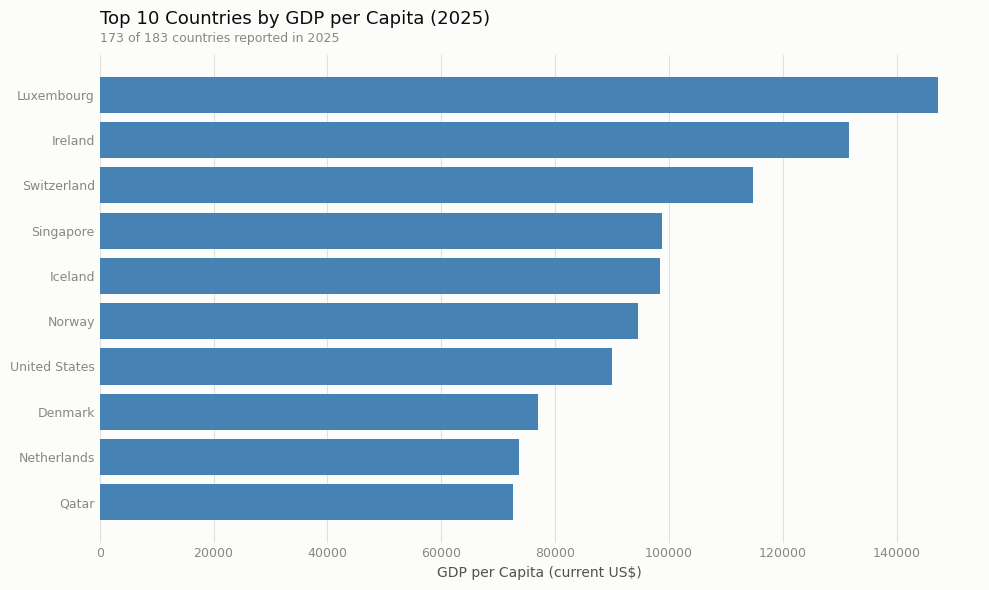

In [6]:
gdp_col = "GDP per capita (current US$)"
freedom_col = "Overall Score"

# Coverage-driven rather than df["Year"].max(); see the note above.
latest_year = utils.latest_complete_year(df, [freedom_col, gdp_col])

fig = viz.plot_top_countries(
    df,
    gdp_col,
    latest_year,
    title=f"Top 10 Countries by GDP per Capita ({latest_year})",
    xlabel="GDP per Capita (current US$)",
    subtitle=utils.coverage_note(df, [gdp_col], latest_year),
    color="steelblue",
)
viz.save_figure(fig, "01-top-countries-gdp-per-capita")
plt.show()

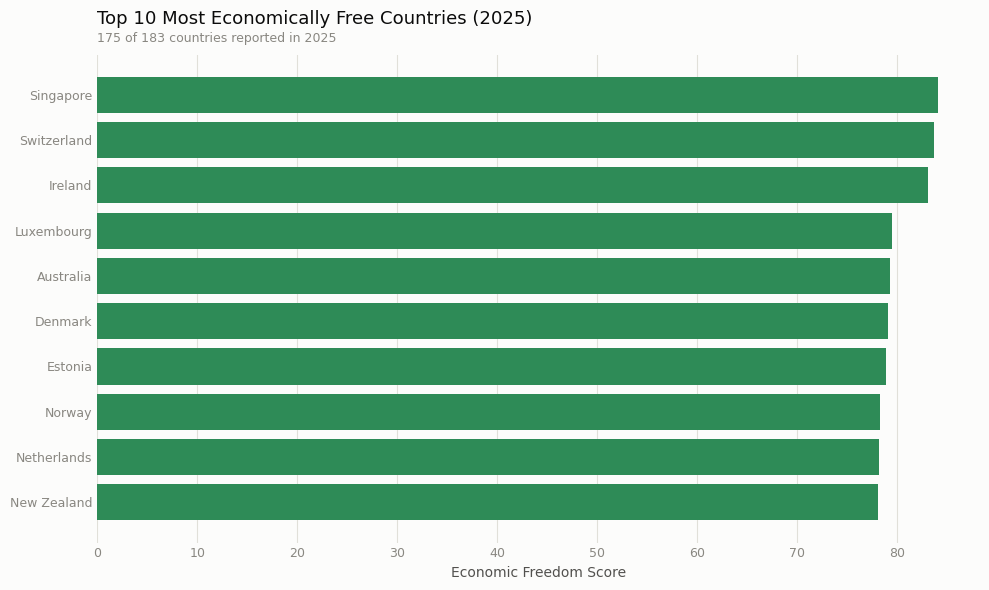

In [7]:
fig = viz.plot_top_countries(
    df,
    freedom_col,
    latest_year,
    title=f"Top 10 Most Economically Free Countries ({latest_year})",
    xlabel="Economic Freedom Score",
    subtitle=utils.coverage_note(df, [freedom_col], latest_year),
    color="seagreen",
)
viz.save_figure(fig, "02-top-countries-freedom")
plt.show()

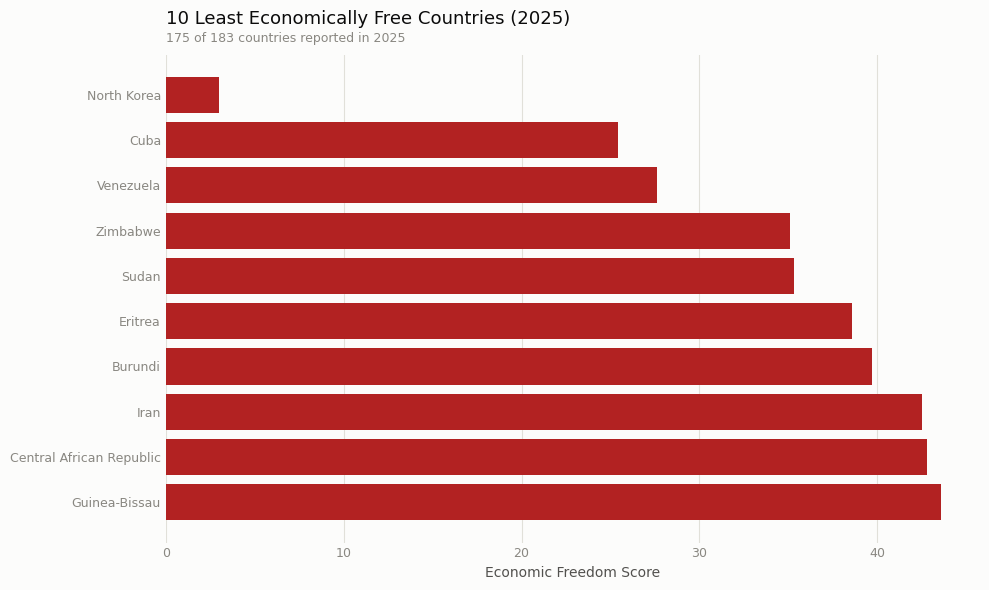

In [8]:
fig = viz.plot_top_countries(
    df,
    freedom_col,
    latest_year,
    title=f"10 Least Economically Free Countries ({latest_year})",
    xlabel="Economic Freedom Score",
    subtitle=utils.coverage_note(df, [freedom_col], latest_year),
    largest=False,
    color="firebrick",
)
viz.save_figure(fig, "03-bottom-countries-freedom")
plt.show()

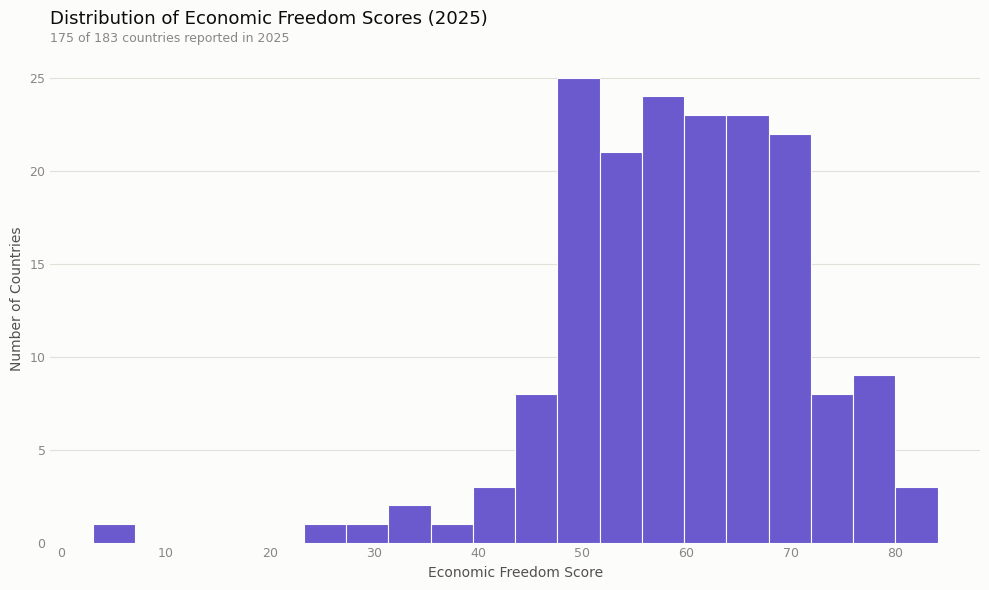

In [9]:
fig = viz.plot_score_distribution(
    df,
    latest_year,
    title=f"Distribution of Economic Freedom Scores ({latest_year})",
    xlabel="Economic Freedom Score",
    subtitle=utils.coverage_note(df, [freedom_col], latest_year),
)
viz.save_figure(fig, "04-freedom-distribution")
plt.show()

In [10]:
# Shown animated; exported as a still, since a PNG holds one frame and
# plotly would otherwise write 2001, the sparsest year in the panel.
viz.save_plotly_figure(
    viz.scatter_freedom_development(df, year=latest_year),
    "05-freedom-vs-gdp-scatter-still",
)
viz.scatter_freedom_development(df).show()

In [11]:
viz.save_plotly_figure(
    viz.choropleth_freedom(df, year=latest_year),
    "06-freedom-choropleth-still",
)
viz.choropleth_freedom(df).show()

> **On the two charts above.** These are the only interactive charts in the notebook, and the stills written to `figures/` are bad images. Both charts run across all 25 years, and in each the movement is the argument: watching a country's trajectory, or the map's colours shifting, together with the hover labels that say *which* country a point belongs to. A single frame has neither.
>
> They are exported only so that something is visible on GitHub, which does not render plotly output. **To read them properly, open this notebook in Colab or Jupyter and run these two cells.** The static panels elsewhere in the notebook lose nothing by being images; these two do.

**Conclusion:** The two rankings overlap heavily. Seven of the ten richest countries in 2025 also appear among the ten freest: Singapore, Switzerland, Ireland, Luxembourg, Denmark, Norway and the Netherlands. The three that do not are Iceland (72.8), the United States (70.2) and Qatar (70.2), all well above the median score of 59.8 but outside the top tier. The gap runs the other way as well: Estonia scores 78.9 on a GDP per capita of $34,418, roughly a quarter of Luxembourg's.

The distribution of scores is unimodal and left-skewed (skew −0.81), with two-thirds of the 175 scored countries falling between 50 and 70. Only three clear 80 and seven sit below 40, so the Index discriminates much more sharply at the bottom than at the top. Income is far more dispersed still: $234 in Burundi against $147,252 in Luxembourg, a 630-fold spread.

One detail recurs in Part V and is worth flagging here. Three of the ten least free countries, North Korea, Cuba and Eritrea, report no GDP per capita at all. That absence is not random with respect to the outcome: any average computed over the reporting countries excludes precisely the states whose figures are missing because of how they are governed, which flatters every summary statistic in this notebook.

## Part III | Relationship Between Economic Freedom and Development Outcomes

Compare countries by economic freedom level against development outcomes such as GDP per capita, life expectancy, and unemployment.

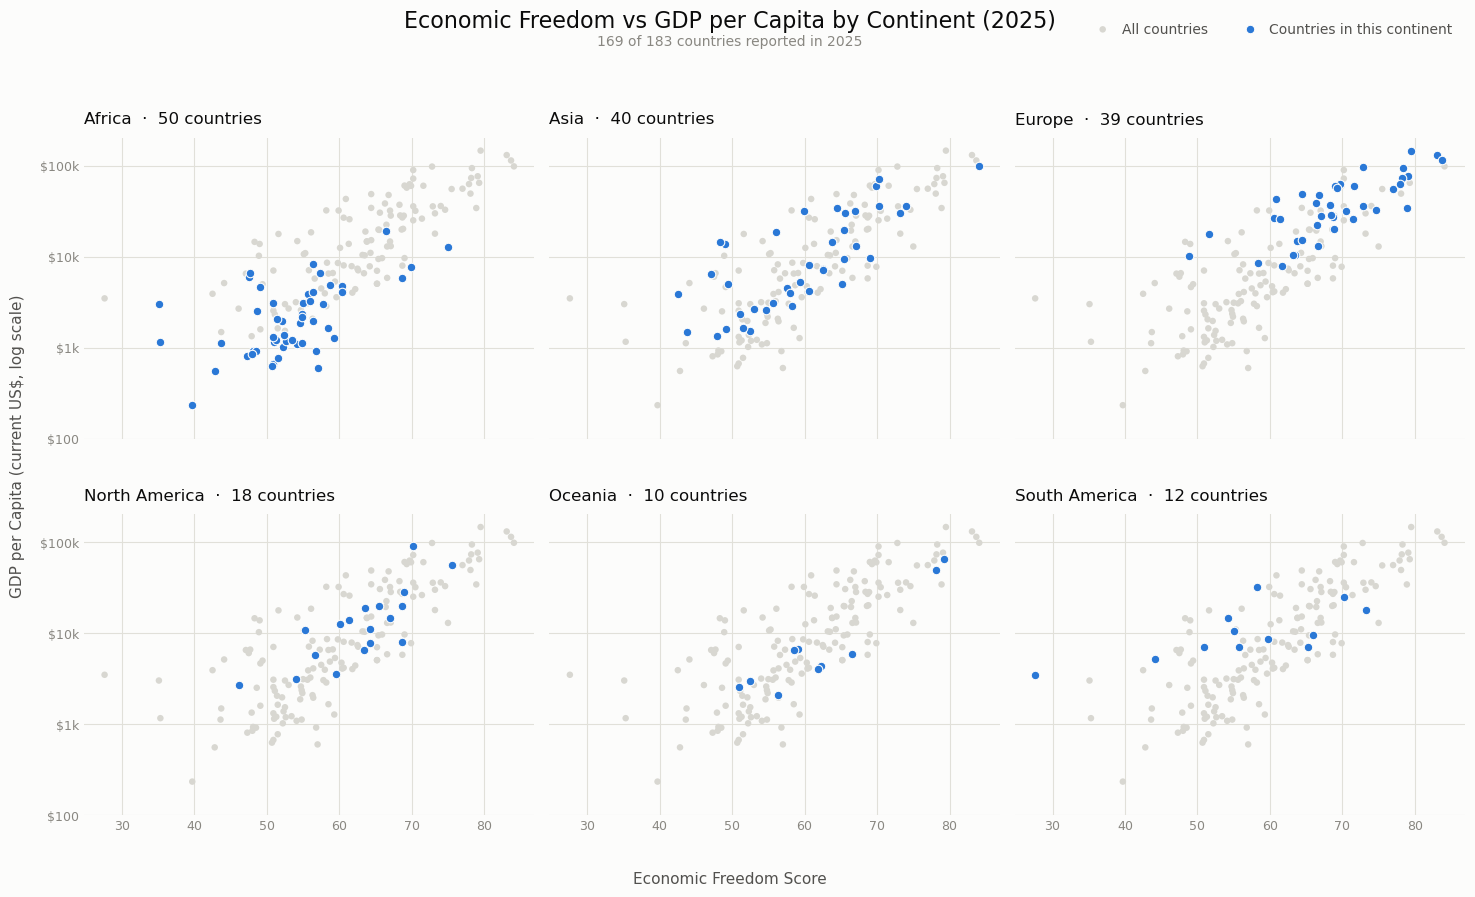

In [12]:
snapshot = df[df["Year"] == latest_year].dropna(subset=[freedom_col, gdp_col])
continents = sorted(snapshot["Continent"].dropna().unique())

fig = viz.plot_continent_overview(
    snapshot,
    continents,
    latest_year,
    gdp_col,
    subtitle=utils.coverage_note(df, [freedom_col, gdp_col], latest_year),
)
viz.save_figure(fig, "07-freedom-vs-gdp-by-continent")
plt.show()

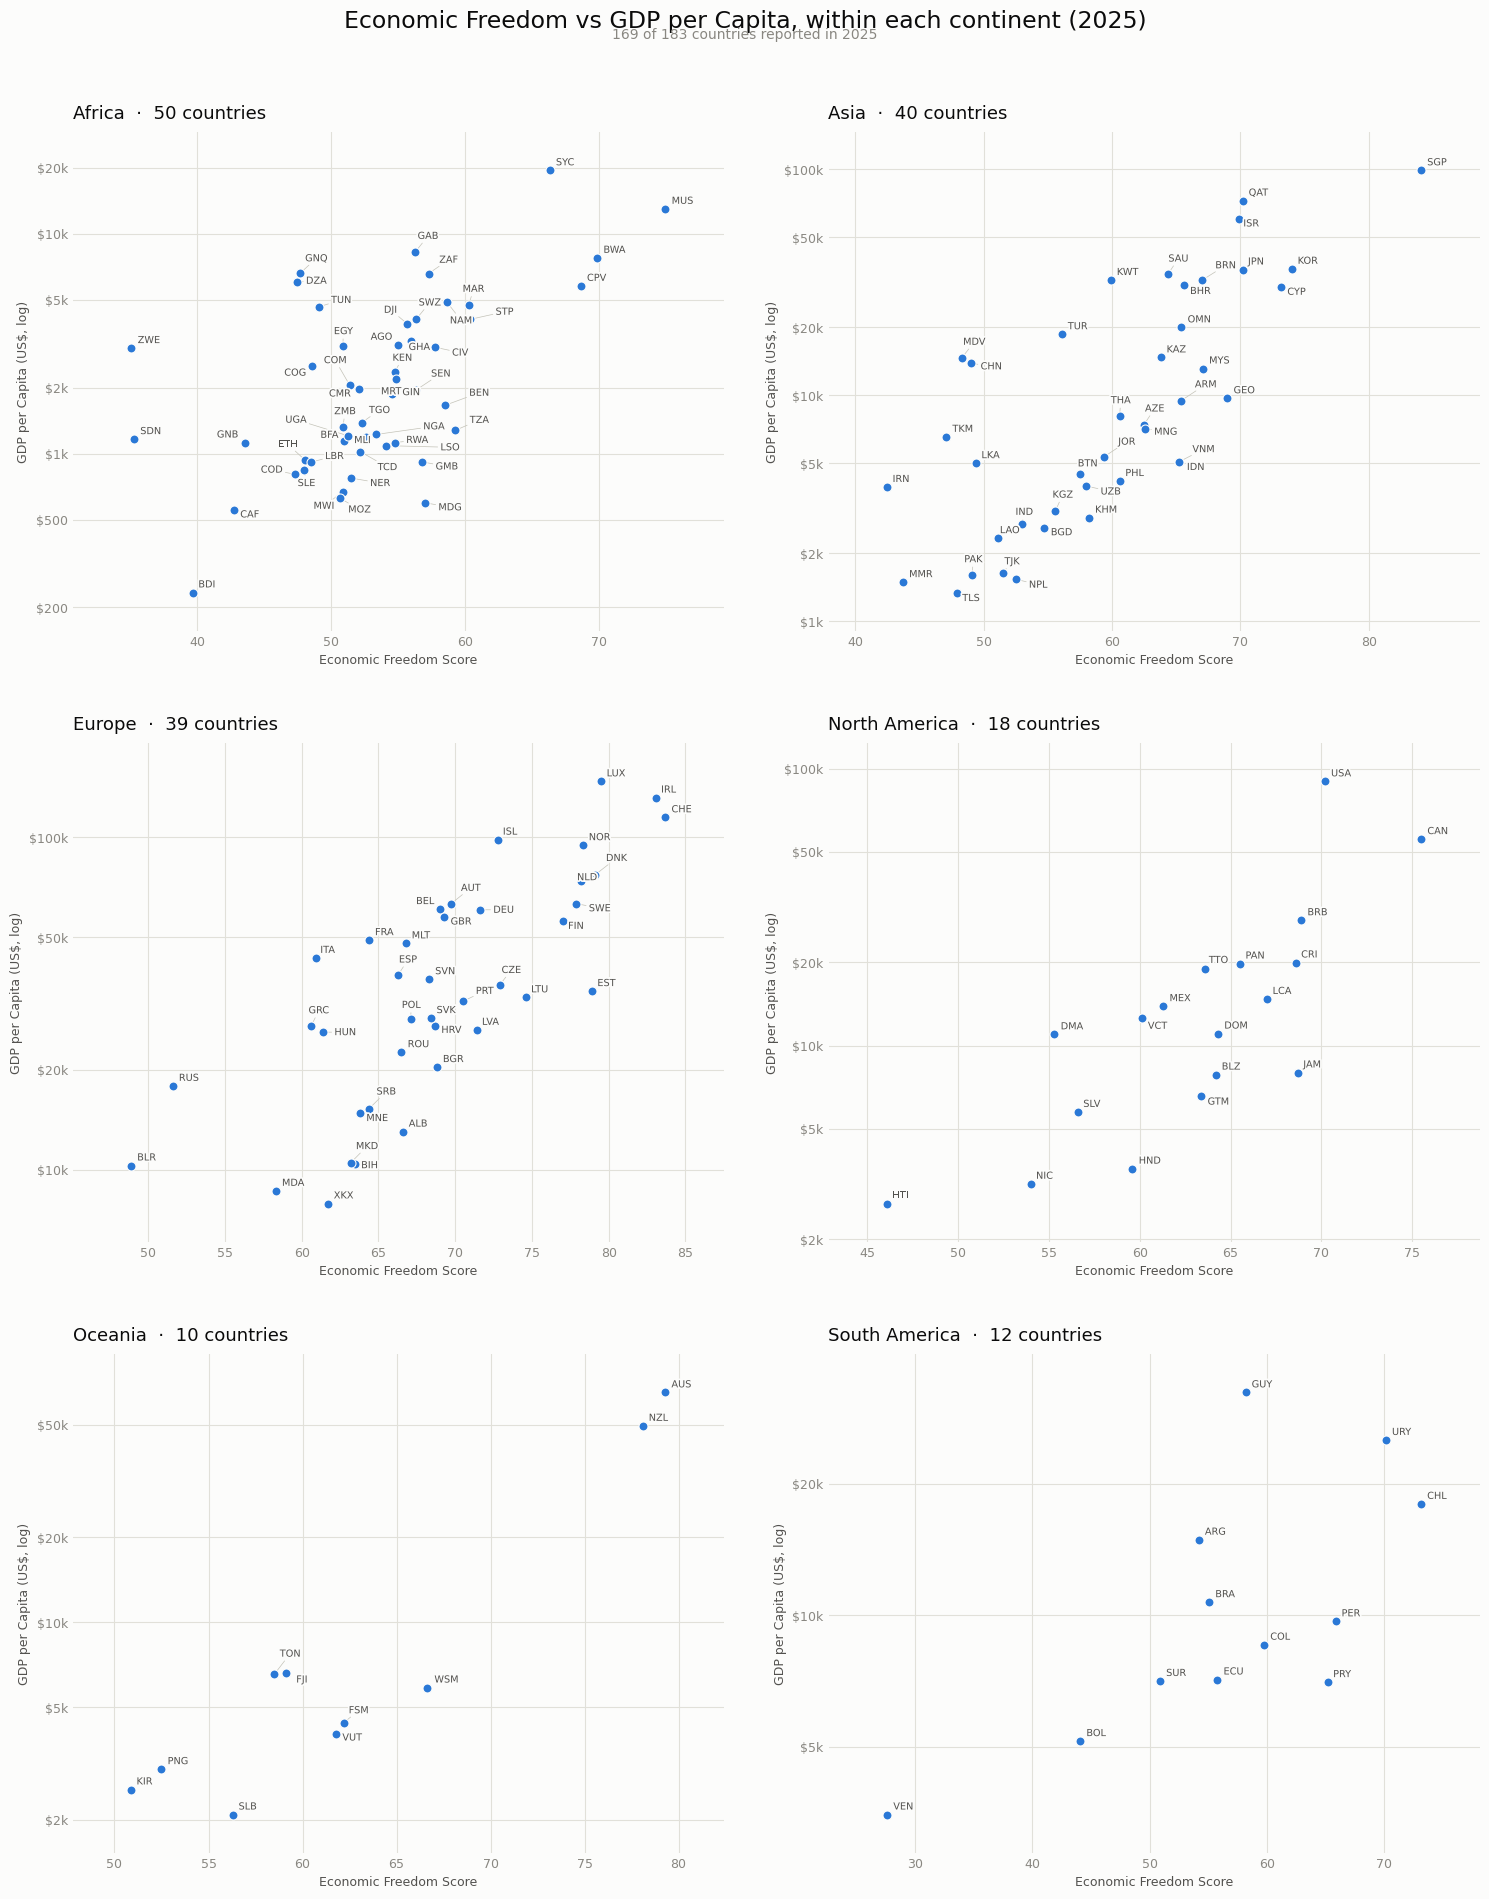

In [13]:
fig = viz.plot_continent_detail(
    snapshot,
    continents,
    latest_year,
    gdp_col,
    subtitle=utils.coverage_note(df, [freedom_col, gdp_col], latest_year),
)
viz.save_figure(fig, "08-freedom-vs-gdp-by-continent-detail")
plt.show()

**Conclusion:** The relationship survives inside every continent. Within-continent correlations between the freedom score and log GDP per capita run 0.57 in Africa, 0.68 in South America, 0.75 in Asia, 0.77 in Europe, 0.79 in North America and 0.93 in Oceania, though Oceania rests on ten countries and should not be over-read. Splitting the world into six geographic groups does not dissolve the pattern into a continent effect.

It does show how much of the raw spread geography alone accounts for. **54.8% of the variance in log GDP per capita sits between continents rather than within them**, and median income runs from $1,916 in Africa to $34,418 in Europe, an eighteen-fold gap between group medians before any country's score is consulted.

The panels also show that the continents are not equally tight. Africa spans an 83-fold range in GDP per capita and Asia 74-fold, against 19-fold in Europe and 9-fold in South America. Africa combines the widest internal spread with the weakest internal correlation, so a single global regression line fits it worst of the six.

## Part IV | Correlation Analysis Across Indicators

Parts II and III established that freer countries are, on the whole, richer countries. This part asks the harder question: *at which level* does that relationship actually hold?

A country-year panel supports two quite different correlations, and a plain `.corr()` averages them together without saying so:

- **Between countries** compares each country's long-run average against every other country's. It answers "do countries scoring higher tend to be richer?".
- **Within countries** removes each country's own average *and* each year's global average, leaving only movement relative to a country's own track record. It answers "when a country's score moves, does its prosperity move with it?".

The year term is not optional. GDP here is in **current US dollars**, so the whole panel drifts upwards with dollar inflation: the panel mean rises 3.25× between 2001 and 2024 before any country does anything at all. Removing the year mean strips that common drift out, whereas a country-only demeaning would leave it in and mistake it for signal.

The relationship is also log-linear rather than linear, so every figure below works on log10 of GDP per capita.

In [14]:
# Logs rather than levels: the pooled correlation with GDP per capita is
# 0.63 in levels against 0.68 in logs, and the continent panels in Part III
# already plot it on a log axis.
log_gdp_col = "GDP per capita (log10, current US$)"
life_col = "Life expectancy at birth, total (years)"

df[log_gdp_col] = utils.log10_column(df[gdp_col])

# The Overall Score alongside the components it is built from, so the chart
# shows whether the aggregate beats its own parts.
components = [freedom_col, *cleaning.FREEDOM_COMPONENTS]

In [15]:
decomposition = utils.correlation_decomposition(
    df, components, log_gdp_col
)
decomposition

,pooled,between,within,countries
component,,,,
Government Integrity,0.777732,0.832489,0.193580,184
Property Rights,0.731692,0.814256,0.159867,184
Business Freedom,0.673538,0.773525,0.178235,184
Overall Score,0.677375,0.709434,0.239507,182
Financial Freedom,0.571646,0.645690,0.079411,183
Trade Freedom,0.553087,0.633126,0.096494,183
Investment Freedom,0.520581,0.597636,0.044304,183
Monetary Freedom,0.311311,0.438191,0.204231,182
Labor Freedom,0.288428,0.357752,0.011754,184


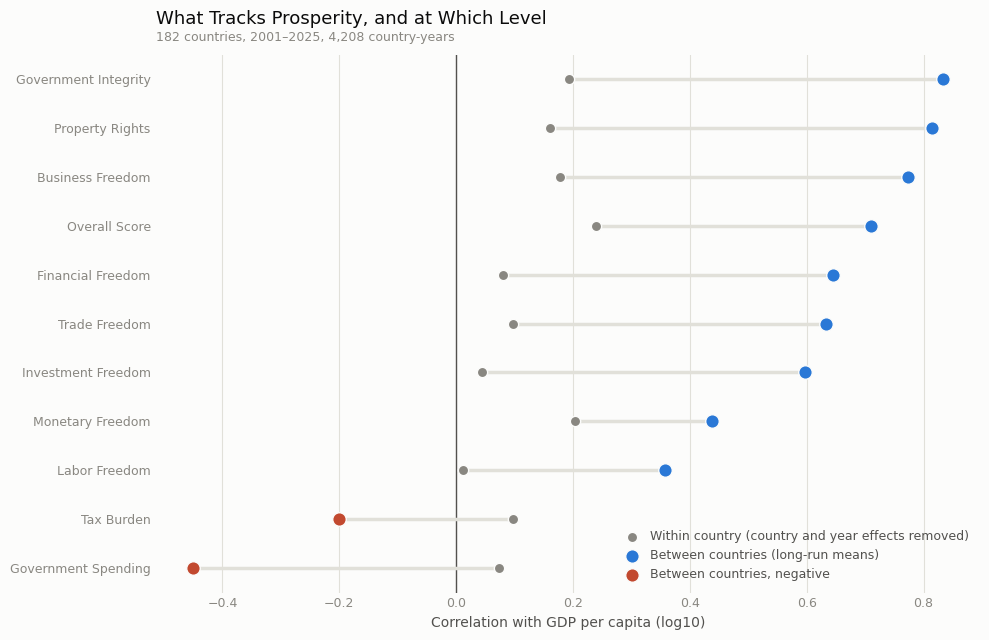

In [16]:
fig = viz.plot_correlation_decomposition(
    decomposition,
    title="What Tracks Prosperity, and at Which Level",
    xlabel="Correlation with GDP per capita (log10)",
    subtitle=utils.panel_note(df, [freedom_col, log_gdp_col]),
)
viz.save_figure(fig, "09-correlation-decomposition")
plt.show()

In [17]:
# Repeated against a second outcome, to check the pattern is not an artefact
# of GDP being measured in current dollars.
utils.correlation_decomposition(df, components, life_col)

,pooled,between,within,countries
component,,,,
Government Integrity,0.644677,0.696792,0.042432,185
Business Freedom,0.581358,0.696166,-0.070475,185
Property Rights,0.607085,0.677405,0.024504,185
Overall Score,0.533366,0.565860,0.027373,183
Trade Freedom,0.483792,0.546907,0.015242,184
Financial Freedom,0.459543,0.519898,-0.034813,184
Investment Freedom,0.431111,0.478684,0.009295,184
Monetary Freedom,0.232787,0.303057,0.094431,183
Labor Freedom,0.201012,0.265168,0.033475,185


**Conclusion:** Three things stand out, and only the first is the expected one.

`Government Integrity` alone correlates 0.83 with GDP per capita across countries, against 0.71 for the `Overall Score` it feeds into, with `Property Rights` (0.81) and `Business Freedom` (0.77) close behind. Averaging the components into a single number costs information here rather than adding it.

Two components point the other way. `Government Spending` correlates −0.45 with prosperity and `Tax Burden` −0.20, so the countries scoring *worst* on the Index's two measures of small government are the rich ones. The `Overall Score` therefore averages components with opposite signs, which is why it lands below its own best parts.

Almost all of the relationship is between countries rather than within them. Every component's within-country correlation collapses towards zero: the `Overall Score` falls from 0.71 to 0.24, `Investment Freedom` from 0.60 to 0.04, `Labor Freedom` from 0.36 to 0.01. Rich countries do score high, but a country raising its own score is only weakly associated with that country growing richer. The same shape holds against life expectancy, where the collapse is starker still (0.57 between, 0.03 within), so it is not an artefact of GDP being denominated in current dollars.

`Tax Burden` is the sharpest illustration, because it reverses sign: −0.20 between countries, +0.10 within them. Compare countries and low taxes look like poverty; follow one country through time and they look mildly like growth. Both readings come from the same column, and a pooled correlation would report neither.

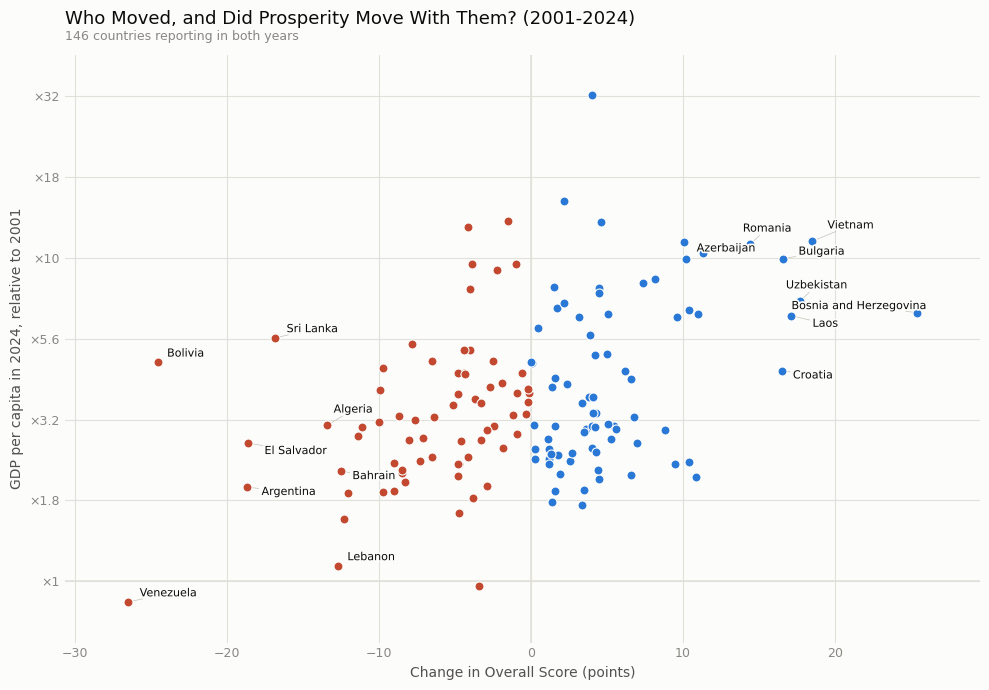

In [18]:
changes = utils.period_change(df, [freedom_col, log_gdp_col], 2001, 2024)

fig = viz.plot_change_scatter(
    changes,
    freedom_col,
    log_gdp_col,
    title="Who Moved, and Did Prosperity Move With Them? (2001-2024)",
    xlabel="Change in Overall Score (points)",
    ylabel="GDP per capita in 2024, relative to 2001",
    subtitle=f"{len(changes)} countries reporting in both years",
    y_formatter=viz.log10_multiple,
)
viz.save_figure(fig, "10-freedom-change-vs-gdp-change")
plt.show()

**Conclusion:** The movers split by region far more cleanly than by any policy label. Every large gain is a transition economy leaving central planning: Bosnia and Herzegovina (+25.4 points), Vietnam (+18.5), Uzbekistan (+17.7), Laos (+17.1), Bulgaria (+16.6), Croatia (+16.5), Romania (+14.4). Every large loss is Latin American or Middle Eastern: Venezuela (−26.5), Bolivia (−24.5), Argentina (−18.7), El Salvador (−18.6).

Across the 146 countries reporting in both years, change in score correlates 0.41 with change in GDP per capita. That is real, and it is also far below the 0.71 the cross-section suggests, consistent with the within-country estimate above rather than with the between-country one.

The scatter also shows why even 0.41 should not be read as an effect. Bolivia lost 24.5 points and still grew 4.8× in current dollars; Venezuela lost 26.5 and ended 13% *poorer*, a figure that says more about the official exchange rate under hyperinflation than about its economy. Several of the red points sit as high as the best blue ones.

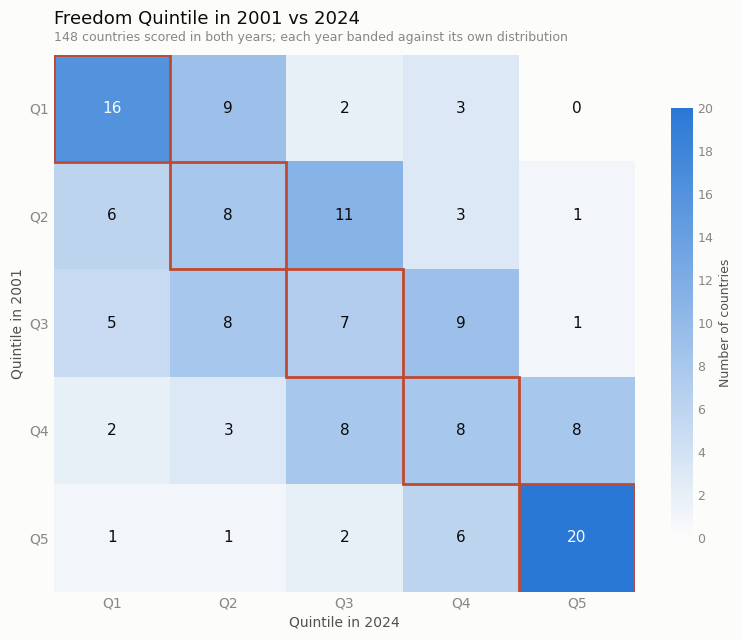

In [19]:
transitions = utils.quantile_transitions(df, freedom_col, 2001, 2024)

fig = viz.plot_transition_matrix(
    transitions,
    title="Freedom Quintile in 2001 vs 2024",
    xlabel="Quintile in 2024",
    ylabel="Quintile in 2001",
    subtitle=(
        f"{transitions.to_numpy().sum()} countries scored in both years; "
        "each year banded against its own distribution"
    ),
)
viz.save_figure(fig, "11-freedom-quintile-transitions")
plt.show()

**Conclusion:** Only 40% of countries (59 of 148) end in the quintile they started in, so the ranking is not frozen, but the mobility is concentrated in the middle. The extremes hold: 16 of 30 bottom-quintile countries in 2001 are still there in 2024, and 20 of 30 top-quintile countries stay at the top, against 23–28% persistence across the three middle bands. Exactly one country falls from the top quintile to the bottom, and none makes the reverse journey.

This is the visible mechanism behind the 0.98–0.99 year-on-year autocorrelation measured on the cleaned dataset. It also explains why the between/within split above matters so much: with countries this persistent, most of the variation available to any pooled statistic is variation between countries that were already different in 2001, not variation any country generated over the following 23 years.

## Part V | Key Findings and Takeaways

Five findings from this notebook, what each one rests on, and where the evidence runs out.

### 1. The relationship is strong, and almost entirely cross-sectional

Across countries the association is hard to miss: in the 2025 snapshot the freedom score correlates **0.79** with log GDP per capita, seven of the ten richest countries sit among the ten freest, and the pattern holds inside all six continents. Over the full panel the between-country correlation is **0.71**.

Within a country it very nearly disappears. Removing each country's own average and each year's global average leaves **0.24** against GDP per capita and **0.03** against life expectancy. The dataset says a great deal about *which* countries are rich and free together, and very little about whether a country that becomes freer becomes richer.

This is the central result here, and a pooled correlation would have hidden it: 0.68 pooled sits between the two levels and describes neither.

### 2. The Overall Score is weaker than its own best component

`Government Integrity` alone correlates **0.83** with prosperity across countries, against **0.71** for the aggregate it feeds into. Two components run the other way, `Government Spending` at **−0.45** and `Tax Burden` at **−0.20**, so the headline score averages measures of opposite sign. `Tax Burden` reverses outright between the two levels: −0.20 between countries, +0.10 within them.

Anyone using a single freedom number is therefore using a figure that cancels part of its own signal. The components are more informative than the index.

### 3. Geography accounts for more than half the raw spread

**54.8%** of the 2025 variance in log GDP per capita sits between continents. The freedom relationship survives that split, holding from 0.57 in Africa to 0.93 in Oceania, but any statement about freedom and income that ignores region is partly a statement about geography.

### 4. Countries move slowly, and the extremes barely move at all

**40%** of countries end 2024 in the quintile they began 2001 in, rising to 53% in the bottom quintile and 67% in the top. The large movers are transition economies gaining (Bosnia and Herzegovina +25.4, Vietnam +18.5) and Latin American economies losing (Venezuela −26.5, Bolivia −24.5). Change in score correlates only **0.41** with change in GDP per capita, close to the within-country estimate and far from the cross-sectional one.

### 5. Missingness is not random with respect to the outcome

Three of the ten least free countries in 2025, North Korea, Cuba and Eritrea, report no GDP per capita at all. Secondary school enrollment behaves the same way: countries that do not report it have a median GDP per capita of $2,510 against $5,801 for those that do.

Every average in this notebook is therefore computed over a sample that excludes some of the poorest and least transparent states. The direction of that bias is known, since it flatters the global picture, even though its size is not.

---

### What the findings rest on

Five properties of the cleaned dataset, each measured in `I-cleaning.ipynb` rather than assumed:

- `GDP per capita` is `GDP / Population` to a relative error of 4.0e-5, bounded by the export's rounding. The three columns carry two independent quantities.
- The mean of the ten remaining sub-components reproduces `Overall Score` with R² = 0.976, which is why finding 2 is about weighting rather than measurement error.
- Year-on-year autocorrelation is 0.98–0.99. This is what makes the between/within distinction in finding 1 necessary rather than decorative.
- A naive `dropna()` cuts 4,581 rows to 2,385 and removes 2001–2004 and all of 2025, so every figure above states the panel it was computed on.
- Missingness tracks the outcome, as finding 5 sets out.

### What this notebook cannot answer

Nothing here supports a causal claim, and three specific things block one.

The outcome is measured in current US dollars, neither PPP-adjusted nor deflated. The panel mean rises 3.25× between 2001 and 2024 before any country does anything. Year effects absorb the common drift, but country-specific exchange-rate swings remain: Venezuela's series reflects the official rate under hyperinflation more than it reflects its economy.

The `Index Year` lag stops being cosmetic. The Heritage Index published for year *N* is graded on data through roughly mid-*N-1*, so the join built into cleaning carries a small offset. For description that is immaterial; for a causal claim the direction and size of that offset is what carries the argument.

Reverse causation is untested and plausible. Rich states can afford independent courts and clean administration, which is largely what `Government Integrity` and `Property Rights` measure. That finding 2 puts those two components at the top of the ranking is at least as consistent with prosperity buying institutions as with the reverse.

So the dataset describes a strong and durable association between institutional quality and national income, locates almost all of it between countries rather than within them, and cannot say which way it runs.